In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
nav = pd.read_csv(
    "../data/processed/02_nav_history_clean.csv"
)

performance = pd.read_csv(
    "../data/processed/07_scheme_performance_clean.csv"
)

benchmark = pd.read_csv(
    "../data/processed/10_benchmark_indices_clean.csv"
)

fund_master = pd.read_csv(
    "../data/processed/01_fund_master_clean.csv"
)

## Daily Returns

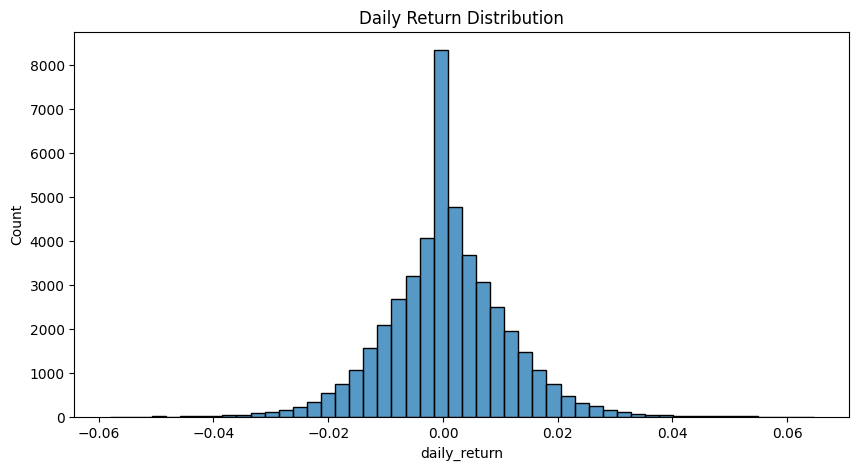

In [3]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")
       ["nav"]
       .pct_change()
)

nav.head()

plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"],
    bins=50
)

plt.title("Daily Return Distribution")

plt.show()

## CAGR

In [4]:
cagr_data = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ]

    start_nav = temp.iloc[0]["nav"]

    end_nav = temp.iloc[-1]["nav"]

    years = (
        temp["date"].max()
        -
        temp["date"].min()
    ).days / 365

    cagr = (
        (end_nav/start_nav)
        **(1/years)
        -1
    )

    cagr_data.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_data,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_df.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)


## Sharpe Ratio

In [5]:
rf = 0.065

sharpe_data = []

for code in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == code
    ]["daily_return"].dropna()

    sharpe = (
        (
            returns.mean()*252
            - rf
        )
        /
        returns.std()
    ) * np.sqrt(252)

    sharpe_data.append(
        [code,sharpe]
    )

    sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=[
        "amfi_code",
        "sharpe"
    ]
)

sharpe_df.to_csv(
    "../data/processed/sharpe_values.csv",
    index=False
)

## Sortino Ratio

In [7]:
sortino_data = []

for code in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == code
    ]["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    sortino = (
        (
            returns.mean()*252
            - rf
        )
        /
        downside.std()
    ) * np.sqrt(252)

    sortino_data.append(
        [code,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_data,
    columns=[
        "amfi_code",
        "sortino"
    ]
)

sortino_df.to_csv(
    "../data/processed/sortino_values.csv",
    index=False
)


## Alpha $ Beta

In [10]:
from scipy.stats import linregress


benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty["return"] = nifty["close_value"].pct_change()


nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)


alpha_beta = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ].copy()

    merged = pd.merge(
        fund,
        nifty[["date", "return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 10:

        slope, intercept, r, p, se = linregress(
            merged["return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append(
            [code, alpha, beta]
        )


alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()


alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [11]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


## Max Drawdown

In [17]:
mdd_data = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    temp["running_max"] = (
        temp["nav"].cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
        -1
    )

    mdd = temp[
        "drawdown"
    ].min()

    mdd_data.append(
        [code,mdd]
    )


maxdd_df = pd.DataFrame(
    mdd_data,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

## Fund Scorecard

In [13]:
scorecard = (
    cagr_df
    .merge(sharpe_df)
    .merge(alpha_beta_df)
    .merge(maxdd_df)
)


scorecard = scorecard.merge(
    performance[["amfi_code", "expense_ratio_pct"]],
    on="amfi_code"
)


scorecard["cagr_rank"] = (
    scorecard["cagr"]
    .rank(ascending=False)
)


scorecard["sharpe_rank"] = (
    scorecard["sharpe"]
    .rank(ascending=False)
)



scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)


scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)


scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)


In [15]:
scorecard["score"] = (
      scorecard["cagr_rank"] * 0.30
    + scorecard["sharpe_rank"] * 0.25
    + scorecard["alpha_rank"] * 0.20
    + scorecard["expense_rank"] * 0.15
    + scorecard["drawdown_rank"] * 0.10
)

scorecard = scorecard.sort_values(
    "score"
)

scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

scorecard.head(10)

,amfi_code,cagr,sharpe,alpha,beta,max_drawdown,expense_ratio_pct,cagr_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,score
25,120505,0.328016,297.385502,0.292636,0.000549,-0.181885,1.36,1.0,5.0,3.0,15.0,25.0,6.900
34,148567,0.309499,364.969375,0.269838,0.023684,-0.112657,1.46,5.0,1.0,7.0,23.0,8.0,7.400
30,120843,0.308833,329.299480,0.273305,-0.022830,-0.129740,1.45,6.0,2.0,5.0,22.0,13.0,7.900
2,100033,0.300997,275.612083,0.271954,0.005104,-0.162172,1.38,7.0,7.0,6.0,17.0,20.0,9.600
36,148569,0.319245,311.202366,0.282704,0.018134,-0.163967,1.60,4.0,3.0,4.0,36.5,21.0,10.325
21,119598,0.323981,238.217681,0.303370,-0.023196,-0.287060,1.43,2.0,14.0,1.0,21.0,36.0,11.050
24,120504,0.232774,258.684120,0.211948,0.016232,-0.125883,0.80,13.0,10.0,13.0,12.0,12.0,12.000
20,119552,0.215080,240.226433,0.198686,-0.026159,-0.118035,0.66,15.0,12.0,15.0,4.0,11.0,12.200
39,149324,0.322621,239.348548,0.300579,0.011455,-0.311719,1.52,3.0,13.0,2.0,26.5,37.0,12.225
19,119551,0.257849,304.483175,0.232010,-0.031751,-0.150124,1.54,10.0,4.0,10.0,30.5,17.0,12.275


## Benchmark Comparison

<Figure size 1400x700 with 0 Axes>

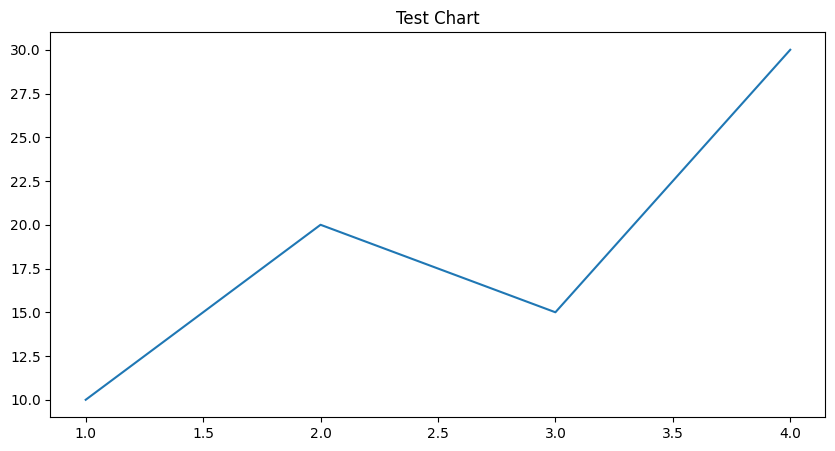

NameError: name 'fig' is not defined

In [ ]:
top5 = (
    scorecard
    .sort_values(
        "score"
    )
    .head(5)
)

plt.figure(figsize=(14,7))


plt.figure(figsize=(10,5))

plt.plot([1,2,3,4],[10,20,15,30])

plt.title("Test Chart")

plt.savefig("../charts/test.png")

plt.show()



Unique Funds: 40
Rows: 46000


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639
